Raw shape: (8765, 54)

================ DATASET ================

Shape:
(8759, 53)

Time range:
2025-01-01 01:00:00 → 2025-12-31 23:00:00

Columns:
se1_metered_consumption_excluding_interruptible_load
se2_metered_consumption_excluding_interruptible_load
se3_metered_consumption_excluding_interruptible_load
se4_metered_consumption_excluding_interruptible_load
se1_metered_consumption_over_50mw
se2_metered_consumption_over_50mw
se3_metered_consumption_over_50mw
se4_metered_consumption_over_50mw
se1_interruptible_load
se2_interruptible_load
se3_interruptible_load
se4_interruptible_load
se1_energy_storage_consumption
se2_energy_storage_consumption
se3_energy_storage_consumption
se4_energy_storage_consumption
se1_metered_losses
se2_metered_losses
se3_metered_losses
se4_metered_losses
se1_unspecified_generation
se2_unspecified_generation
se3_unspecified_generation
se4_unspecified_generation
se1_hydro_generation
se2_hydro_generation
se3_hydro_generation
se4_hydro_generation
se1_wind_generation

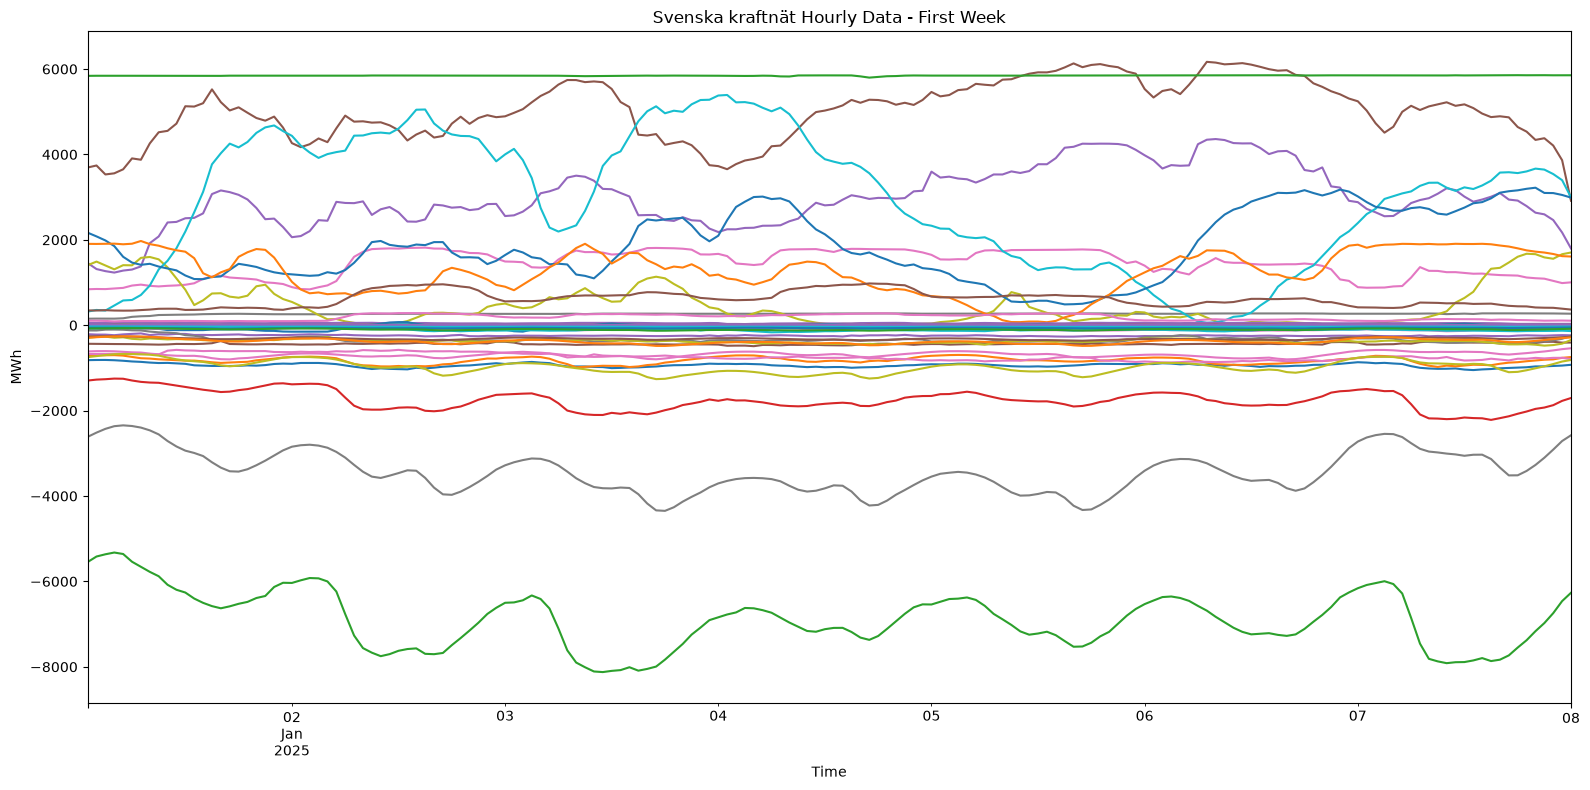


Saved: svk_2025_english.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. READ THE COMPLETE EXCEL FILE
# ============================================================

file_path = "data/raw/timvarden-2025-01-12.xls"

# Read the first sheet without assuming a header structure
raw = pd.read_excel(
    file_path,
    sheet_name=0,
    header=None,
    engine="xlrd"
)

print("Raw shape:", raw.shape)


# ============================================================
# 2. CREATE ENGLISH COLUMN NAMES
# ============================================================

# The SvK file has:
# row 0 = main category
# row 1 = subcategory
# row 2 = bidding zone
# row 3 = unit
#
# We combine these pieces into one English column name.

main_translation = {
    "Timmätt förbr": "metered_consumption",
    "Avkopplingsbar": "interruptible",
    "Energilager": "energy_storage",
    "Timmätta": "metered",
    "Ospec.": "unspecified",
    "Vattenkraft": "hydro",
    "Vindkraft": "wind",
    "Kärnkraft": "nuclear",
    "Värmekraft": "thermal",
    "Solkraft": "solar",
    "Schablonleverans": "profiled_supply"
}

sub_translation = {
    "exkl. avk.last": "excluding_interruptible_load",
    ">50 MW": "over_50MW",
    "last": "load",
    "förbrukning": "consumption",
    "förluster": "losses",
    "produktion": "generation"
}


def translate(value, dictionary):
    """Translate Swedish header text into English."""
    if pd.isna(value):
        return ""

    value = str(value).strip()
    return dictionary.get(value, value)


english_columns = ["datetime"]

# Build column names automatically from the Excel header
for col in range(1, raw.shape[1]):

    main = translate(raw.iloc[0, col], main_translation)
    sub = translate(raw.iloc[1, col], sub_translation)
    zone = str(raw.iloc[2, col]).strip()

    parts = [zone, main, sub]

    # Remove empty / nan parts
    parts = [
        p for p in parts
        if p not in ["", "nan", "None"]
    ]

    column_name = "_".join(parts)

    # Clean column name
    column_name = (
        column_name
        .replace(" ", "_")
        .replace(".", "")
        .lower()
    )

    english_columns.append(column_name)


# ============================================================
# 3. EXTRACT THE ACTUAL DATA
# ============================================================

# Data starts after the header rows
df = raw.iloc[6:].copy()

df.columns = english_columns

df = df.reset_index(drop=True)


# ============================================================
# 4. CLEAN DATA TYPES
# ============================================================

# Convert timestamp
df["datetime"] = pd.to_datetime(
    df["datetime"],
    dayfirst=True,
    errors="coerce"
)

# Remove rows without valid timestamps
df = df.dropna(subset=["datetime"])

# Convert every other column to numeric
for col in df.columns[1:]:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# Sort chronologically
df = df.sort_values("datetime")

# Use datetime as index
df = df.set_index("datetime")


# ============================================================
# 5. BASIC INFORMATION
# ============================================================

print("\n================ DATASET ================\n")

print("Shape:")
print(df.shape)

print("\nTime range:")
print(df.index.min(), "→", df.index.max())

print("\nColumns:")
for col in df.columns:
    print(col)

print("\nFirst rows:")
print(df.head())

print("\nLast rows:")
print(df.tail())


# ============================================================
# 6. MISSING VALUES
# ============================================================

missing = df.isna().sum()

missing = missing[missing > 0].sort_values(
    ascending=False
)

print("\n================ MISSING VALUES ================\n")

if len(missing) == 0:
    print("No missing values.")
else:
    print(missing)


# ============================================================
# 7. DESCRIPTIVE STATISTICS
# ============================================================

summary = df.describe().T

summary["missing"] = df.isna().sum()

summary["missing_percent"] = (
    df.isna().mean() * 100
)

print("\n================ SUMMARY STATISTICS ================\n")

print(
    summary[
        [
            "count",
            "mean",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max",
            "missing",
            "missing_percent"
        ]
    ]
)


# ============================================================
# 8. CHECK TIME INTERVALS
# ============================================================

time_difference = (
    df.index
    .to_series()
    .diff()
    .value_counts()
)

print("\n================ TIME INTERVALS ================\n")

print(time_difference.head(10))


# ============================================================
# 9. SIMPLE PLOT OF NUMERIC VARIABLES
# ============================================================

# Plot first 7 days only so the figure remains readable

first_week = df.iloc[:24 * 7]

first_week.plot(
    figsize=(16, 8),
    legend=False
)

plt.title("Svenska kraftnät Hourly Data - First Week")
plt.xlabel("Time")
plt.ylabel("MWh")
plt.tight_layout()
plt.show()


# ============================================================
# 10. SAVE CLEAN ENGLISH DATASET
# ============================================================

# df.to_csv(
#     "svk_2025_english.csv",
#     encoding="utf-8"
# )

# print("\nSaved: svk_2025_english.csv")

In [9]:
df.head()
df.filter(like='hydro').head()

,se1_hydro_generation,se2_hydro_generation,se3_hydro_generation,se4_hydro_generation
datetime,,,,
2025-01-01 01:00:00,1457.335636,3693.417963,842.258858,152.506648
2025-01-01 02:00:00,1315.607942,3741.089156,848.832673,154.894713
2025-01-01 03:00:00,1266.788969,3531.293587,846.260873,154.092254
2025-01-01 04:00:00,1233.087148,3557.582647,859.273700,154.039008
2025-01-01 05:00:00,1279.841094,3651.655192,874.566307,162.805802
